In [1]:
# Import necessary libraries
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
import torch.nn.functional as F


# Load the preprocessed dataset
data_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

data_dir = 'processed_dataset'
full_dataset = datasets.ImageFolder(data_dir, transform=data_transform)

# Split the dataset into train, validation, and test sets
train_size = int(0.7 * len(full_dataset))
val_size = int(0.15 * len(full_dataset))
test_size = len(full_dataset) - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# Create DataLoaders
batch_size = 16
dataloaders = {
    'train': DataLoader(train_dataset, batch_size=batch_size, shuffle=True),
    'val': DataLoader(val_dataset, batch_size=batch_size, shuffle=False),
    'test': DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
}
dataset_sizes = {'train': train_size, 'val': val_size, 'test': test_size}
class_names = full_dataset.classes
num_classes = len(class_names)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Number of classes: {num_classes}")


Number of classes: 720


In [2]:
import torch
import torch.nn as nn
from torchvision import models

# Define Self-Attention mechanism
class SelfAttention(nn.Module):
    def __init__(self, in_channels):
        super(SelfAttention, self).__init__()
        self.query = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.key = nn.Conv2d(in_channels, in_channels // 8, kernel_size=1)
        self.value = nn.Conv2d(in_channels, in_channels, kernel_size=1)
        self.gamma = nn.Parameter(torch.zeros(1))  # Learnable scaling parameter

    def forward(self, x):
        batch_size, channels, height, width = x.size()

        # Compute query, key, and value
        query = self.query(x).view(batch_size, -1, height * width)  # [B, C/8, H*W]
        key = self.key(x).view(batch_size, -1, height * width)  # [B, C/8, H*W]
        value = self.value(x).view(batch_size, -1, height * width)  # [B, C, H*W]

        # Compute attention map
        attention = torch.bmm(query.permute(0, 2, 1), key)  # [B, H*W, H*W]
        attention = torch.softmax(attention, dim=-1)  # Normalize across spatial positions

        # Compute self-attention output
        out = torch.bmm(value, attention)  # [B, C, H*W]
        out = out.view(batch_size, channels, height, width)  # Reshape back to feature map dimensions

        # Scale and combine with input
        out = self.gamma * out + x  # Apply learnable scaling and residual connection
        return out

class ResNetWithSelfAttention(nn.Module):
    def __init__(self, num_classes):
        super(ResNetWithSelfAttention, self).__init__()
        self.backbone = models.resnet50(pretrained=True)
        self.backbone.conv1 = nn.Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        self.backbone.fc = nn.Linear(self.backbone.fc.in_features, num_classes)

        # Add self-attention
        self.self_attention = SelfAttention(in_channels=2048)  # 2048 is the number of channels after layer4

    def forward(self, x):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        # Apply self-attention
        attention_map = self.self_attention(x)

        x = self.backbone.avgpool(attention_map)  # Apply pooling on attended features
        x = torch.flatten(x, 1)
        output = self.backbone.fc(x)
        return output, attention_map  # Return both predictions and attention map


# Load the Parent Model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_classes = 720  # Update based on your dataset
parent_model = ResNetWithSelfAttention(num_classes=num_classes).to(device)

# Load the state dictionary for the parent model
parent_model_path = "attention_mechanism_self.pth"  # Update the path to your saved model
parent_model.load_state_dict(torch.load(parent_model_path, map_location=device))
parent_model.eval()  # Set the model to evaluation mode

print("Parent model loaded successfully.")


C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\f34rjagu\AppData\Local\Temp\ipykernel_10040\1217139401.py:71: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See htt

Parent model loaded successfully.


In [3]:
class ChildResNet(nn.Module):
    def __init__(self, num_classes):
        super(ChildResNet, self).__init__()
        self.backbone = models.resnet50(pretrained=True)
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(self.backbone.fc.in_features, num_classes)
        )

    def forward(self, x, return_features=False):
        x = self.backbone.conv1(x)
        x = self.backbone.bn1(x)
        x = self.backbone.relu(x)
        x = self.backbone.maxpool(x)

        x = self.backbone.layer1(x)
        x = self.backbone.layer2(x)
        x = self.backbone.layer3(x)
        x = self.backbone.layer4(x)

        if return_features:
            return x  # Return features from layer4

        x = self.backbone.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.backbone.fc(x)
        return x




child_model = ChildResNet(num_classes=num_classes).to(device)

# Define Loss Functions and Optimizers
criterion = nn.CrossEntropyLoss()
parent_optimizer = optim.SGD(parent_model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)
child_optimizer = optim.SGD(child_model.parameters(), lr=0.001, momentum=0.9, weight_decay=1e-4)


In [4]:
def train_child_with_parent(parent_model, child_model, dataloaders, criterion, child_optimizer, dataset_sizes, num_epochs=25):
    for epoch in range(num_epochs):
        print(f"Epoch {epoch + 1}/{num_epochs}")
        print("-" * 10)

        parent_model.eval()  # Freeze the parent model
        child_model.train()  # Train the child model

        running_loss = 0.0
        running_corrects = 0

        # Training Phase
        for inputs, labels in dataloaders['train']:
            inputs, labels = inputs.to(device), labels.to(device)

            # Zero the gradients
            child_optimizer.zero_grad()

            # Forward pass through the parent model to get attention maps
            with torch.no_grad():
                _, attention_map = parent_model(inputs)

            # Forward pass through the child model to get features
            child_features = child_model(inputs, return_features=True)

            # Resize attention map to match child features
            attention_map_resized = F.interpolate(
                attention_map, size=child_features.shape[2:], mode='bilinear', align_corners=False
            )

            # Compute loss
            classification_outputs = child_model(inputs)  # Get final logits
            classification_loss = criterion(classification_outputs, labels)
            attention_penalty = torch.mean((attention_map_resized - child_features) ** 2)  # Regularize based on parent's attention
            total_loss = classification_loss + 0.1 * attention_penalty

            # Backward pass
            total_loss.backward()
            child_optimizer.step()

            _, preds = torch.max(classification_outputs, 1)
            running_loss += total_loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels)

        epoch_loss = running_loss / dataset_sizes['train']
        epoch_acc = running_corrects.double() / dataset_sizes['train']
        print(f"Train Loss: {epoch_loss:.4f} Train Acc: {epoch_acc:.4f}")

        # Validation Phase
        child_model.eval()
        val_loss = 0.0
        val_corrects = 0
        with torch.no_grad():
            for inputs, labels in dataloaders['val']:
                inputs, labels = inputs.to(device), labels.to(device)

                # Forward pass
                classification_outputs = child_model(inputs)
                loss = criterion(classification_outputs, labels)

                _, preds = torch.max(classification_outputs, 1)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels)

        val_epoch_loss = val_loss / dataset_sizes['val']
        val_epoch_acc = val_corrects.double() / dataset_sizes['val']
        print(f"Val Loss: {val_epoch_loss:.4f} Val Acc: {val_epoch_acc:.4f}")

    # Save the child model
    torch.save(child_model.state_dict(), "trained_child_self.pth")
    print("Child model training complete and saved.")


In [6]:

# Call the training function
train_child_with_parent(
    parent_model=parent_model,
    child_model=child_model,
    dataloaders=dataloaders,
    criterion=criterion,
    child_optimizer=child_optimizer,
    dataset_sizes=dataset_sizes,
    num_epochs=25  # You can adjust the number of epochs as needed
)

Epoch 1/25
----------
Train Loss: 7.2250 Train Acc: 0.0930
Val Loss: 4.5222 Val Acc: 0.2714
Epoch 2/25
----------
Train Loss: 5.1436 Train Acc: 0.4163
Val Loss: 2.4479 Val Acc: 0.6300
Epoch 3/25
----------
Train Loss: 3.3899 Train Acc: 0.7530
Val Loss: 1.0882 Val Acc: 0.8621
Epoch 4/25
----------
Train Loss: 2.3367 Train Acc: 0.9265
Val Loss: 0.4618 Val Acc: 0.9444
Epoch 5/25
----------
Train Loss: 1.8504 Train Acc: 0.9817
Val Loss: 0.2107 Val Acc: 0.9777
Epoch 6/25
----------
Train Loss: 1.6471 Train Acc: 0.9965
Val Loss: 0.1366 Val Acc: 0.9842
Epoch 7/25
----------
Train Loss: 1.5630 Train Acc: 0.9991
Val Loss: 0.1143 Val Acc: 0.9831
Epoch 8/25
----------
Train Loss: 1.5193 Train Acc: 0.9998
Val Loss: 0.0887 Val Acc: 0.9858
Epoch 9/25
----------
Train Loss: 1.4925 Train Acc: 0.9996
Val Loss: 0.0826 Val Acc: 0.9875
Epoch 10/25
----------
Train Loss: 1.4762 Train Acc: 0.9998
Val Loss: 0.0783 Val Acc: 0.9847
Epoch 11/25
----------
Train Loss: 1.4672 Train Acc: 0.9999
Val Loss: 0.0731 Va

In [9]:
# Import necessary lib raries
import torch
from torchvision import transforms, datasets
from PIL import Image
import torch.nn.functional as F

# Define a function to load the trained child model
def load_child_model(model_path, num_classes):
    class ChildResNet(nn.Module):
        def __init__(self, num_classes):
            super(ChildResNet, self).__init__()
            self.backbone = models.resnet50(pretrained=True)
            self.backbone.fc = nn.Sequential(
                nn.Dropout(0.5),
                nn.Linear(self.backbone.fc.in_features, num_classes)
            )

        def forward(self, x):
            x = self.backbone(x)
            return x

    # Initialize the model and load the weights
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = ChildResNet(num_classes=num_classes).to(device)
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval()  # Set model to evaluation mode
    print("Child model loaded successfully.")
    return model

# Load the child model
model_path = "trained_child_self.pth"  # Path to your saved child model
child_model = load_child_model(model_path, num_classes=num_classes)

# Define a function to preprocess an input image
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),  # Resize to match training size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    image = Image.open(image_path).convert("RGB")  # Ensure 3-channel RGB image
    input_tensor = transform(image).unsqueeze(0)  # Add batch dimension
    return input_tensor, image

# Test the model on an input image
def test_child_model(model, image_path, class_names):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    input_tensor, original_image = preprocess_image(image_path)
    input_tensor = input_tensor.to(device)

    with torch.no_grad():
        outputs = model(input_tensor)
        _, predicted = torch.max(outputs, 1)
        class_index = predicted.item()
        class_name = class_names[class_index]

    print(f"Predicted Class: {class_name}")

    # Display the input image
    #original_image.show(title=f"Predicted: {class_name}")

# Path to a test image
test_image_path = "combined_dataset/00001/003.bmp"  # Replace with the path to your test image

# Test the child model
test_child_model(child_model, test_image_path, class_names)


C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\f34rjagu\AppData\Local\Temp\ipykernel_10040\434144338.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See http

Child model loaded successfully.
Predicted Class: 00001


In [11]:
# Function to evaluate the model on the test set
def evaluate_model(model, dataloader, criterion):
    model.eval()  # Set model to evaluation mode
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    total_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)

            # Forward pass
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    avg_loss = total_loss / len(dataloader)
    accuracy = 100 * correct / total

    print(f"Test Loss: {avg_loss:.4f}, Test Accuracy: {accuracy:.2f}%")
    return avg_loss, accuracy

# Load the trained child model
model_path = "trained_child_self👍😎.pth"  # Path to your saved child model
child_model = load_child_model(model_path, num_classes=num_classes)

# Evaluate the model on the test set
criterion = nn.CrossEntropyLoss()
evaluate_model(child_model, dataloaders['test'], criterion)


C:\Users\f34rjagu\AppData\Local\Temp\ipykernel_10040\434144338.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location

Child model loaded successfully.
Test Loss: 0.0761, Test Accuracy: 98.64%


(0.0761306003201753, 98.63908546543277)

C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\Users\f34rjagu\AppData\Local\Temp\ipykernel_10040\434144338.py:25: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See http

Child model loaded successfully.


C:\Users\f34rjagu\AppData\Roaming\Python\Python312\site-packages\torch\nn\modules\module.py:1640: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


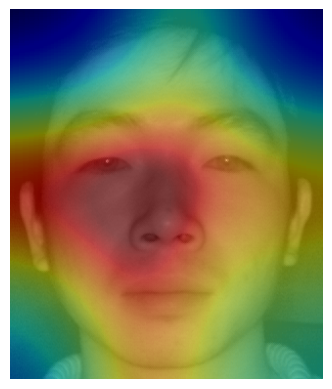

Compactness (lower is better): 1.3598
High-Intensity Ratio (higher is better): 0.8125


In [21]:
# Import necessary libraries for Grad-CAM
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
from torchvision import transforms
from PIL import Image

# Grad-CAM Class
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.gradients = None

        # Hooks to capture gradients and features
        self.target_layer.register_forward_hook(self.save_features)
        self.target_layer.register_backward_hook(self.save_gradients)

    def save_features(self, module, input, output):
        self.features = output

    def save_gradients(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def __call__(self, input_tensor, class_idx=None):
        self.model.eval()
        input_tensor = input_tensor.to(device)

        # Forward pass
        output = self.model(input_tensor)
        if class_idx is None:
            class_idx = torch.argmax(output, dim=1).item()

        # Backward pass for the predicted class
        self.model.zero_grad()
        target = output[0, class_idx]
        target.backward()

        # Pool the gradients
        pooled_gradients = torch.mean(self.gradients, dim=[0, 2, 3])
        for i in range(self.features.size(1)):
            self.features[0, i, :, :] *= pooled_gradients[i]

        # Generate heatmap
        heatmap = torch.mean(self.features, dim=1).squeeze()
        heatmap = F.relu(heatmap)
        heatmap /= torch.max(heatmap)
        return heatmap.cpu().detach().numpy()

# Preprocess an input image for Grad-CAM
def preprocess_image(image_path):
    transform = transforms.Compose([
        transforms.Resize((128, 128)),  # Resize to match training size
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
    ])
    image = Image.open(image_path).convert("RGB")  # Ensure 3-channel RGB image
    input_tensor = transform(image).unsqueeze(0)  # Add batch dimension
    return input_tensor, image

# Overlay the Grad-CAM heatmap on the original image
def overlay_heatmap(img, heatmap):
    heatmap = np.uint8(255 * heatmap)
    heatmap = Image.fromarray(heatmap).resize((img.width, img.height), Image.Resampling.LANCZOS)
    heatmap = np.array(heatmap)

    plt.imshow(img)
    plt.imshow(heatmap, cmap='jet', alpha=0.5)  # Overlay heatmap with transparency
    plt.axis('off')
    plt.show()

# Metric 1: Compactness of Heatmap
def calculate_compactness(heatmap):
    # Normalize heatmap
    heatmap = heatmap / heatmap.max()

    # Find coordinates of high-intensity regions
    threshold = 0.5  # Adjust based on desired focus level
    high_intensity_coords = np.argwhere(heatmap > threshold)

    # Compute compactness (average distance to centroid)
    if len(high_intensity_coords) > 0:
        centroid = np.mean(high_intensity_coords, axis=0)
        distances = np.linalg.norm(high_intensity_coords - centroid, axis=1)
        compactness = np.mean(distances)
        return compactness
    else:
        return float('inf')  # Return infinity if no high-intensity regions are found

# Metric 2: Ratio of High-Intensity Region
def calculate_high_intensity_ratio(heatmap):
    # Normalize heatmap
    heatmap = heatmap / heatmap.max()

    # Calculate ratio of high-intensity pixels to total pixels
    threshold = 0.5  # Adjust based on desired focus level
    high_intensity_pixels = np.sum(heatmap > threshold)
    total_pixels = heatmap.size
    return high_intensity_pixels / total_pixels

# Generate Grad-CAM and Quantify
def generate_gradcam_with_metrics(image_path):
    # Preprocess the image
    input_tensor, original_image = preprocess_image(image_path)

    # Generate Grad-CAM heatmap
    heatmap = grad_cam(input_tensor)

    # Overlay the heatmap on the original image
    overlay_heatmap(original_image, heatmap)

    # Quantify Grad-CAM
    compactness = calculate_compactness(heatmap)
    high_intensity_ratio = calculate_high_intensity_ratio(heatmap)

    print(f"Compactness (lower is better): {compactness:.4f}")
    print(f"High-Intensity Ratio (higher is better): {high_intensity_ratio:.4f}")

# Load the trained child model
model_path = "trained_child_self.pth"  # Path to your saved child model
child_model = load_child_model(model_path, num_classes=num_classes)

# Define the target layer for Grad-CAM (last convolutional layer)
target_layer = child_model.backbone.layer4[-1]  # Modify if the layer is different
grad_cam = GradCAM(child_model, target_layer)

# Test the Grad-CAM implementation
image_path = "001.bmp"  # Replace with the path to your test image
generate_gradcam_with_metrics(image_path)


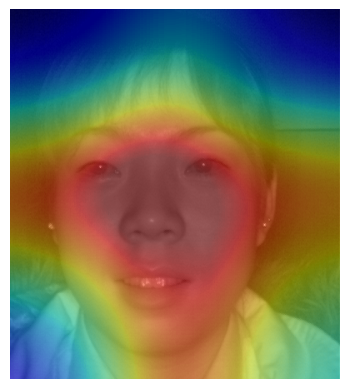

Compactness (lower is better): 1.3967
High-Intensity Ratio (higher is better): 0.8750


In [22]:
# Test the Grad-CAM implementation
image_path = "combined_dataset\\00182\\003.bmp"  # Replace with the path to your image
generate_gradcam_with_metrics(image_path)

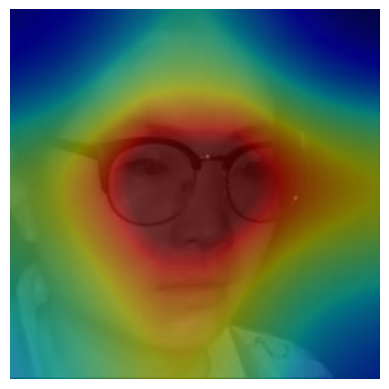

Compactness (lower is better): 1.3467
High-Intensity Ratio (higher is better): 0.8125


In [23]:
# Preprocess the input image
image_path = "LAMPHQ\\P0046\\NIR_P0046_1_LEFT_b.jpg"  # Path to the NIR image
generate_gradcam_with_metrics(image_path)

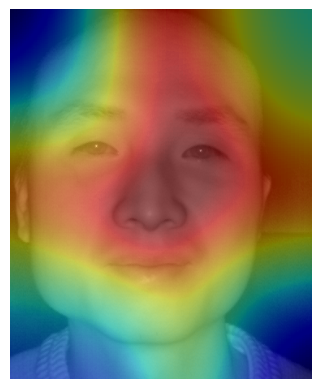

Compactness (lower is better): 1.4086
High-Intensity Ratio (higher is better): 0.8750


In [24]:
# Preprocess the input image
image_path = "combined_dataset\\00003\\001.bmp"  # Path to the NIR image
generate_gradcam_with_metrics(image_path)

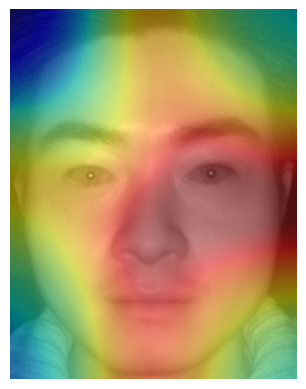

Compactness (lower is better): 1.4509
High-Intensity Ratio (higher is better): 0.9375


In [25]:
# Preprocess the input image 
image_path = "combined_dataset\\00046\\003.bmp"  # Path to the NIR image
generate_gradcam_with_metrics(image_path)